# CityBrain EDA — Vancouver Pavement Risk Assessment

**COMP9130 Final Project — Group 5**

| Branch | Model | Input Data |
|--------|-------|------------|
| Pavement Condition | MLP | PCI ratings, segment length |
| Temporal | BiLSTM | Weather (90-day windows) + 311 complaint frequency |
| Geospatial | MLP | Street classification, ROW width, repair history |

## 0. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT_ROOT = '/content/drive/MyDrive/AI-FinalProject'
DATA_DIR = f'{PROJECT_ROOT}/data'
FIG_DIR = f'{PROJECT_ROOT}/figures'

import os
os.makedirs(FIG_DIR, exist_ok=True)
print('Data files:', sorted(os.listdir(DATA_DIR)))

Mounted at /content/drive
Data files: ['311_service_requests_2009_2021.csv', '311_service_requests_full.csv', 'city_project_package_street.csv', 'directional_traffic_count_locations.csv', 'intersection_traffic_movement_counts.csv', 'pavement_condition.csv', 'pavement_condition_major_road_network.csv', 'public_streets.csv', 'right_of_way_widths.csv', 'road_ahead_current_road_closures.csv', 'road_ahead_projects_under_construction.csv', 'road_ahead_upcoming_projects.csv', 'weather_vancouver.csv']


In [2]:
!pip install geopandas shapely pyproj -q

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Point, LineString, shape
import ast, json, warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
RISK_COLORS = {'Low': '#2ecc71', 'Medium': '#f39c12', 'High': '#e74c3c'}

def save_fig(name):
    plt.savefig(f'{FIG_DIR}/{name}.png', bbox_inches='tight', dpi=150)
    print(f'  Saved -> figures/{name}.png')

---
## 1. Data Loading

- Pavement and 311 CSVs use **semicolon** separator
- Weather and infrastructure CSVs use **comma** separator
- Geometry formats differ: JSON (pavement) vs Python dict (infrastructure)

In [4]:
def safe_load(filename, **kwargs):
    path = f'{DATA_DIR}/{filename}'
    if not os.path.exists(path):
        print(f'  NOT FOUND: {filename}')
        return None
    with open(path, 'r', encoding='utf-8', errors='replace') as f:
        first_line = f.readline()
    sep = ';' if first_line.count(';') > first_line.count(',') else ','
    df = pd.read_csv(path, sep=sep, on_bad_lines='skip', **kwargs)
    print(f'  {filename}: {df.shape[0]:,} rows x {df.shape[1]} cols (sep="{sep}")')
    return df

print('=== Loading Datasets ===\n')
print('[Pavement Condition]')
df_pave_local = safe_load('pavement_condition.csv')
df_pave_major = safe_load('pavement_condition_major_road_network.csv')

print('\n[311 Service Requests]')
COLS_311 = ['Department', 'Service request type', 'Service request open timestamp',
            'Address', 'Local area', 'Latitude', 'Longitude']
df_311_new = safe_load('311_service_requests_full.csv', usecols=COLS_311)
df_311_old = safe_load('311_service_requests_2009_2021.csv', usecols=COLS_311)

print('\n[Weather]')
df_weather = safe_load('weather_vancouver.csv')

print('\n[Infrastructure]')
df_streets = safe_load('public_streets.csv')
df_row = safe_load('right_of_way_widths.csv')
df_traffic = safe_load('directional_traffic_count_locations.csv')

print('\n[Repair History]')
df_repairs = safe_load('city_project_package_street.csv')

=== Loading Datasets ===

[Pavement Condition]
  pavement_condition.csv: 9,016 rows x 8 cols (sep=";")
  pavement_condition_major_road_network.csv: 5,404 rows x 8 cols (sep=";")

[311 Service Requests]
  311_service_requests_full.csv: 1,161,515 rows x 7 cols (sep=";")
  311_service_requests_2009_2021.csv: 2,083,091 rows x 7 cols (sep=";")

[Weather]
  weather_vancouver.csv: 2,557 rows x 31 cols (sep=",")

[Infrastructure]
  public_streets.csv: 1,710 rows x 4 cols (sep=",")
  right_of_way_widths.csv: 2,690 rows x 3 cols (sep=",")
  directional_traffic_count_locations.csv: 670 rows x 3 cols (sep=",")

[Repair History]
  city_project_package_street.csv: 40 rows x 6 cols (sep=",")


In [5]:
all_dfs = {
    'Pavement (Local)': df_pave_local, 'Pavement (Major)': df_pave_major,
    '311 (2022+)': df_311_new, '311 (2009-2021)': df_311_old,
    'Weather': df_weather, 'Streets': df_streets,
    'ROW Widths': df_row, 'Traffic Locations': df_traffic,
    'Repair History': df_repairs,
}
rows = []
for name, df in all_dfs.items():
    if df is not None:
        rows.append({'Dataset': name, 'Rows': f'{df.shape[0]:,}', 'Cols': df.shape[1],
                     'Missing %': f'{df.isnull().mean().mean()*100:.1f}%',
                     'Duplicates': f'{df.duplicated().sum():,}',
                     'Memory MB': f'{df.memory_usage(deep=True).sum()/1e6:.1f}'})
pd.DataFrame(rows).set_index('Dataset')

,Rows,Cols,Missing %,Duplicates,Memory MB
Dataset,,,,,
Pavement (Local),"9,016",8,0.0%,0,6.1
Pavement (Major),"5,404",8,0.8%,0,2.8
311 (2022+),"1,161,515",7,31.6%,"5,799",398.5
311 (2009-2021),"2,083,091",7,25.8%,783,728.4
Weather,"2,557",31,41.4%,0,1.6
Streets,"1,710",4,0.0%,"1,700",0.9
ROW Widths,"2,690",3,0.0%,"2,680",0.8
Traffic Locations,670,3,0.0%,660,0.3
Repair History,40,6,0.0%,30,0.0


---
## 2. Pavement Condition (Branch 1: PCI-MLP)

Vancouver provides PCI as categorical ratings. We map to numeric scores and 3-class risk labels.

In [6]:
df_pave_local['road_type'] = 'local'
if df_pave_major is not None:
    df_pave_major['road_type'] = 'major'
    df_pavement = pd.concat([df_pave_local, df_pave_major], ignore_index=True)
else:
    df_pavement = df_pave_local.copy()
print(f'Combined: {len(df_pavement):,} segments')
print(f'Columns: {list(df_pavement.columns)}')
df_pavement.head(3)

Combined: 14,420 segments
Columns: ['Year', 'Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating', 'Geom', 'geo_point_2d', 'road_type']


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,Geom,geo_point_2d,road_type
0,2020,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,"{""coordinates"": [[-123.02596132078351, 49.2263...","49.22637498558873, -123.02535015595373",local
1,2020,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,"{""coordinates"": [[-123.15124781549908, 49.2151...","49.215083474080224, -123.1498338331115",local
2,2020,29TH AV,ELGIN ST,ROSS ST,101,POOR,"{""coordinates"": [[-123.08272270544481, 49.2446...","49.244605930447584, -123.08202889157728",local


In [7]:
print('Raw PCI Rating distribution:')
print(df_pavement['PCI Rating'].value_counts())
print(f'\n"NO DATA" rows: {(df_pavement["PCI Rating"] == "NO DATA").sum()}')

Raw PCI Rating distribution:
PCI Rating
VERY GOOD    3247
FAIR         3061
GOOD         2833
VERY POOR    2441
POOR         2182
NO DATA       656
Name: count, dtype: int64

"NO DATA" rows: 656


In [8]:
PCI_MAP = {'VERY GOOD': 90, 'GOOD': 75, 'FAIR': 55, 'POOR': 35, 'VERY POOR': 15}
df_pavement['pci_score'] = df_pavement['PCI Rating'].map(PCI_MAP)

def pci_to_risk(s):
    if pd.isna(s): return np.nan
    if s >= 70: return 'Low'
    if s >= 40: return 'Medium'
    return 'High'

df_pavement['risk_label'] = df_pavement['pci_score'].apply(pci_to_risk)
n_before = len(df_pavement)
df_pavement = df_pavement.dropna(subset=['risk_label']).reset_index(drop=True)
print(f'Dropped {n_before - len(df_pavement)} NO DATA rows')
print(f'Remaining: {len(df_pavement):,} segments\n')
print(df_pavement[['PCI Rating','pci_score','risk_label']].drop_duplicates().sort_values('pci_score', ascending=False).to_string(index=False))

Dropped 656 NO DATA rows
Remaining: 13,764 segments

PCI Rating  pci_score risk_label
 VERY GOOD       90.0        Low
      GOOD       75.0        Low
      FAIR       55.0     Medium
      POOR       35.0       High
 VERY POOR       15.0       High


  Saved -> figures/01_risk_distribution.png


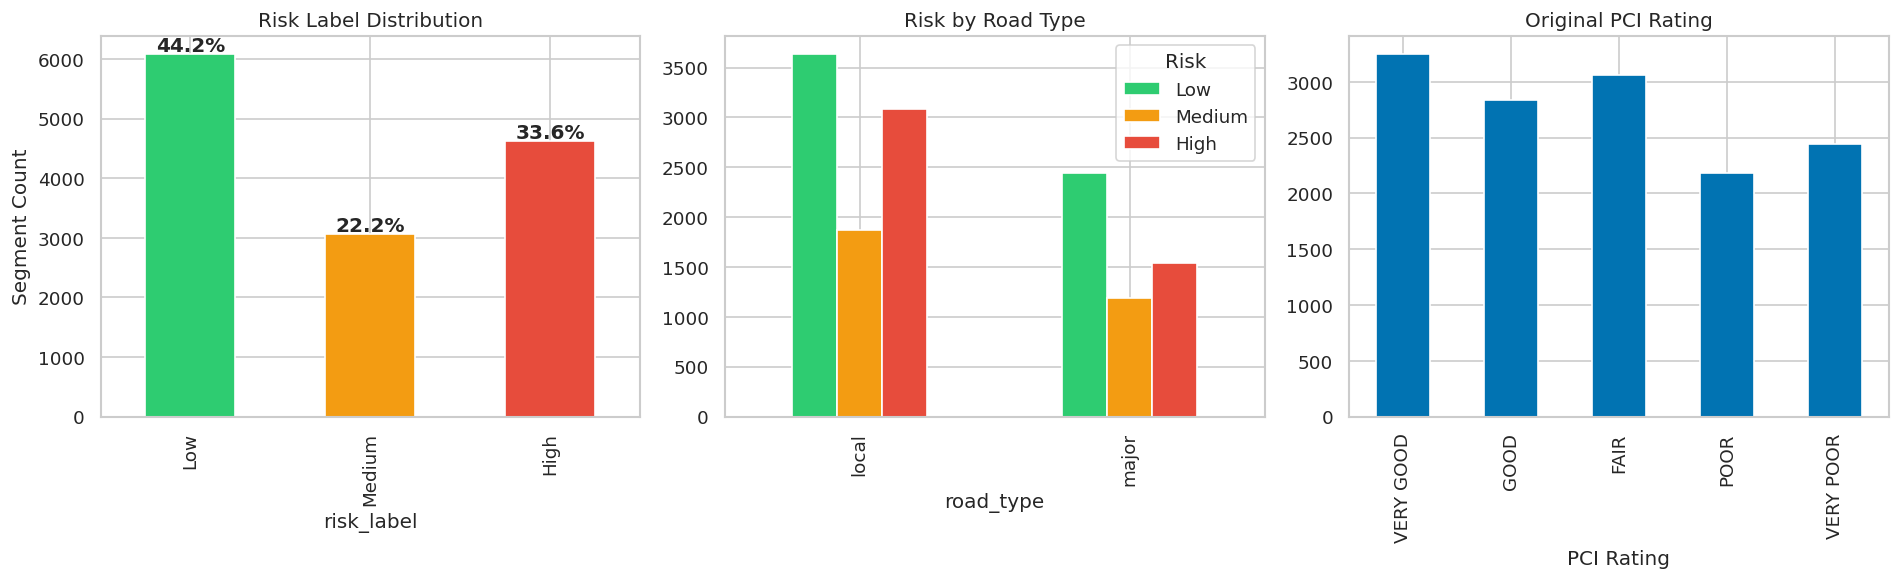


Imbalance ratio: 2.0:1


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
risk_counts = df_pavement['risk_label'].value_counts().reindex(['Low','Medium','High'])
risk_counts.plot.bar(ax=axes[0], color=[RISK_COLORS[x] for x in risk_counts.index])
axes[0].set_title('Risk Label Distribution')
axes[0].set_ylabel('Segment Count')
for i, (label, count) in enumerate(risk_counts.items()):
    axes[0].text(i, count+50, f'{count/len(df_pavement)*100:.1f}%', ha='center', fontweight='bold')

ct = pd.crosstab(df_pavement['road_type'], df_pavement['risk_label'])
ct[['Low','Medium','High']].plot.bar(ax=axes[1], color=[RISK_COLORS['Low'],RISK_COLORS['Medium'],RISK_COLORS['High']])
axes[1].set_title('Risk by Road Type')
axes[1].legend(title='Risk')

order = ['VERY GOOD','GOOD','FAIR','POOR','VERY POOR']
df_pavement['PCI Rating'].value_counts().reindex(order).plot.bar(ax=axes[2])
axes[2].set_title('Original PCI Rating')
plt.tight_layout()
save_fig('01_risk_distribution')
plt.show()
print(f'\nImbalance ratio: {risk_counts.max()/risk_counts.min():.1f}:1')

  Saved -> figures/02_segment_length_vs_risk.png


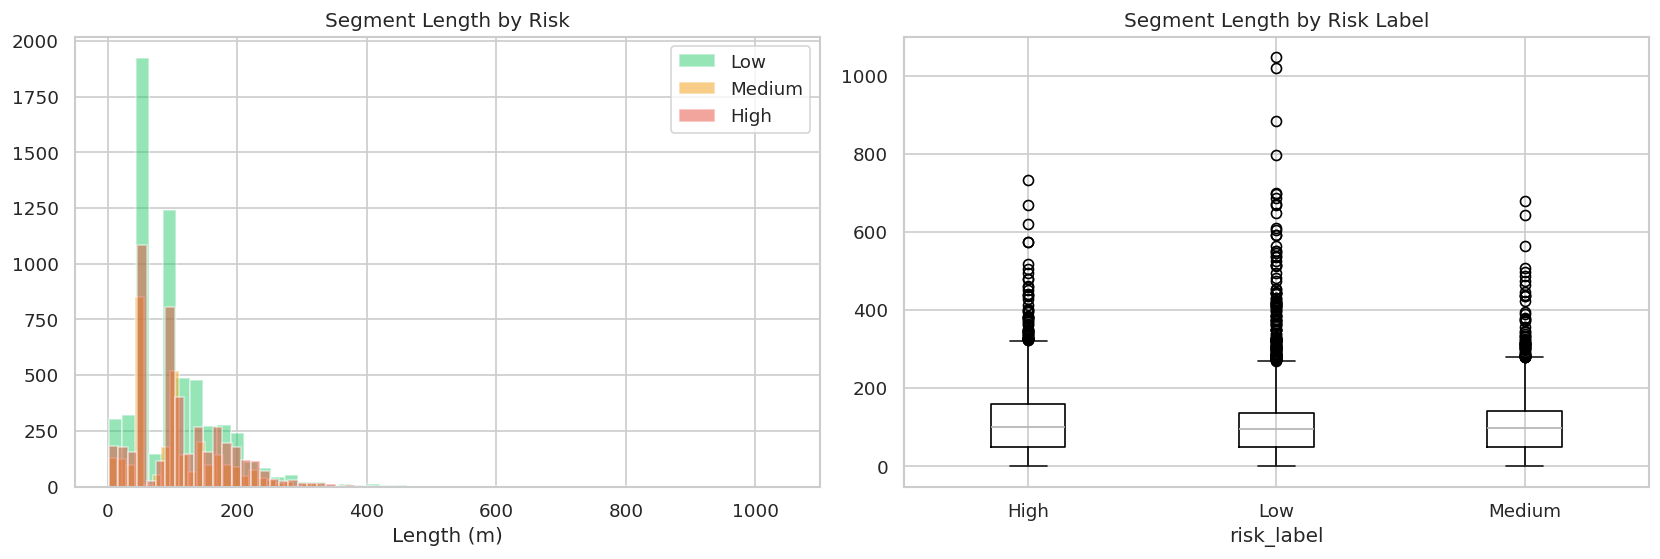

             count   mean   std  min   25%    50%    75%     max
risk_label                                                      
High        4623.0  112.4  73.6  1.0  50.0  101.0  159.0   732.0
Low         6080.0  102.2  75.8  1.0  50.0   97.0  138.0  1047.0
Medium      3061.0  105.4  71.7  1.0  50.0   99.0  142.0   680.0


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for risk in ['Low','Medium','High']:
    subset = df_pavement[df_pavement['risk_label']==risk]['length_(m)']
    axes[0].hist(subset, bins=50, alpha=0.5, label=risk, color=RISK_COLORS[risk])
axes[0].set_title('Segment Length by Risk')
axes[0].set_xlabel('Length (m)')
axes[0].legend()
df_pavement.boxplot(column='length_(m)', by='risk_label', ax=axes[1])
axes[1].set_title('Segment Length by Risk Label')
plt.suptitle('')
plt.tight_layout()
save_fig('02_segment_length_vs_risk')
plt.show()
print(df_pavement.groupby('risk_label')['length_(m)'].describe().round(1))

---
## 3. 311 Service Requests (Branch 2 input)

**Limitation:** Only ~33% of records have coordinates. We use the geolocated subset for spatial joins.

In [11]:
dfs_311 = [df for df in [df_311_new, df_311_old] if df is not None]
df_311 = pd.concat(dfs_311, ignore_index=True)
print(f'Combined 311: {len(df_311):,} rows')

df_311['date'] = pd.to_datetime(df_311['Service request open timestamp'], errors='coerce', utc=True)
df_311['date'] = df_311['date'].dt.tz_convert('America/Vancouver').dt.tz_localize(None)
print(f'Date range: {df_311["date"].min()} -> {df_311["date"].max()}')

has_coords = df_311[['Latitude','Longitude']].notna().all(axis=1).sum()
print(f'With coordinates: {has_coords:,} / {len(df_311):,} ({has_coords/len(df_311)*100:.1f}%)')

Combined 311: 3,244,606 rows
Date range: 2009-02-16 15:18:54 -> 2026-04-08 21:57:16
With coordinates: 1,291,420 / 3,244,606 (39.8%)


In [12]:
ROAD_KEYWORDS = ['pothole','pavement','road','street','asphalt','crack','sinkhole',
                 'surface','paving','curb','manhole','bump','depression','repair']
mask = pd.Series(False, index=df_311.index)
for col in ['Department','Service request type']:
    col_lower = df_311[col].fillna('').str.lower()
    for kw in ROAD_KEYWORDS:
        mask |= col_lower.str.contains(kw, na=False)
df_311_road = df_311[mask].copy()
print(f'Road-related: {len(df_311_road):,} / {len(df_311):,} ({len(df_311_road)/len(df_311)*100:.1f}%)')
print(f'\nTop 10 types:')
print(df_311_road['Service request type'].value_counts().head(10).to_string())

Road-related: 428,905 / 3,244,606 (13.2%)

Top 10 types:
Service request type
Street Light Out Case                            77086
Pothole Case                                     46318
Street Repair Case                               41028
Street Cleaning and Debris Pick Up Case          37949
Street Surface Water Flooding Case               31307
Sidewalk Repair Case                             22674
Sign Repair Case                                 20060
Vegetation Encroachment of City Property Case    17692
Traffic Signal Repair Case                       14381
Urban Issues on City Property Case               12616


  Saved -> figures/03_311_temporal_patterns.png


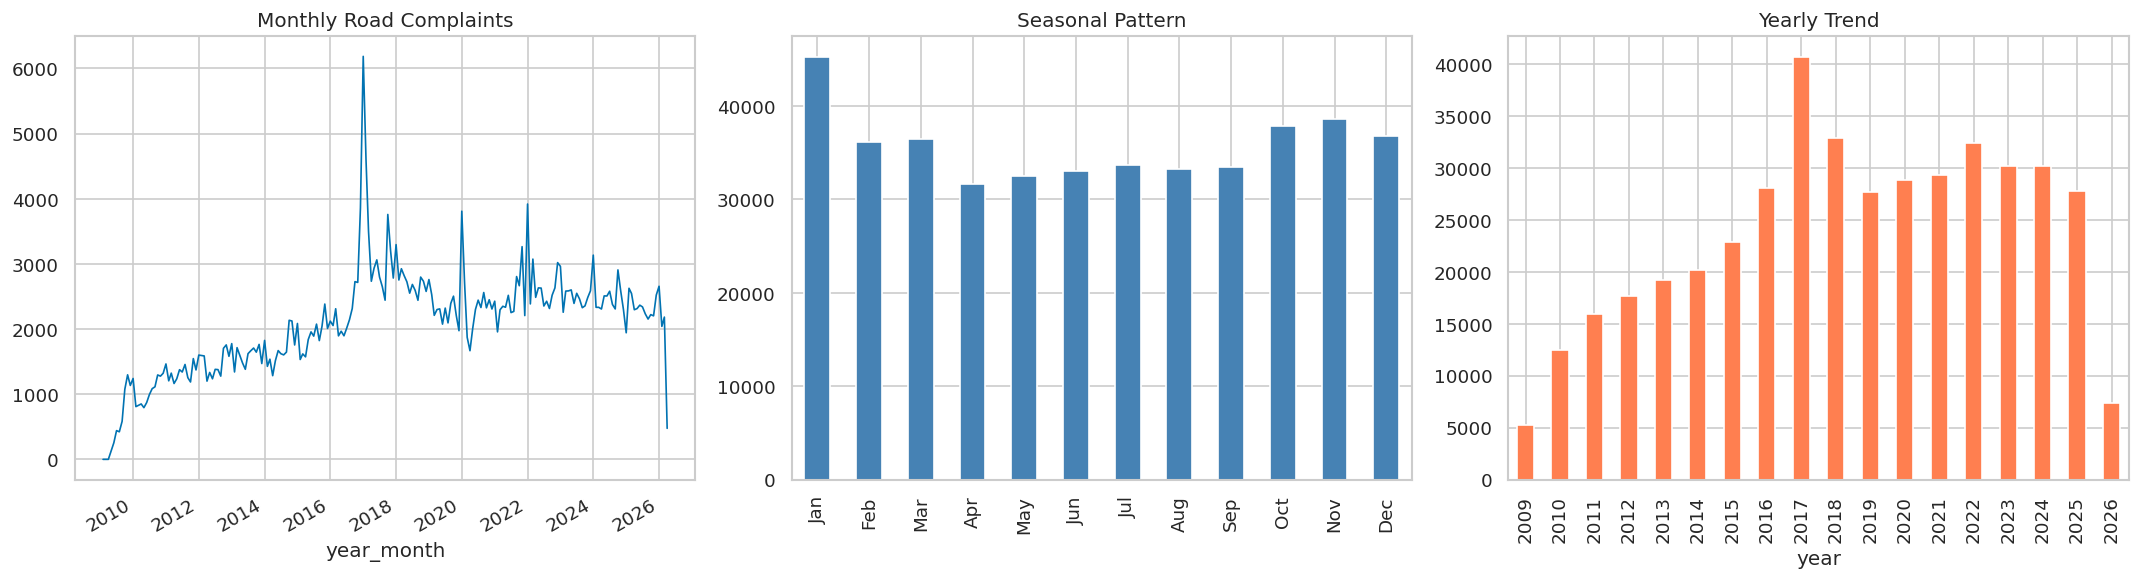

In [13]:
df_311_road = df_311_road.dropna(subset=['date']).copy()
df_311_road['year'] = df_311_road['date'].dt.year
df_311_road['month'] = df_311_road['date'].dt.month
df_311_road['year_month'] = df_311_road['date'].dt.to_period('M')
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
monthly = df_311_road.groupby('year_month').size()
monthly.index = monthly.index.to_timestamp()
monthly.plot(ax=axes[0], linewidth=1)
axes[0].set_title('Monthly Road Complaints')

seasonal = df_311_road.groupby('month').size()
seasonal.index = [month_names[i-1] for i in seasonal.index]
seasonal.plot.bar(ax=axes[1], color='steelblue')
axes[1].set_title('Seasonal Pattern')

yearly = df_311_road.groupby('year').size()
yearly.plot.bar(ax=axes[2], color='coral')
axes[2].set_title('Yearly Trend')
plt.tight_layout()
save_fig('03_311_temporal_patterns')
plt.show()

Road complaints with coords: 393,406
  Saved -> figures/04_311_spatial.png


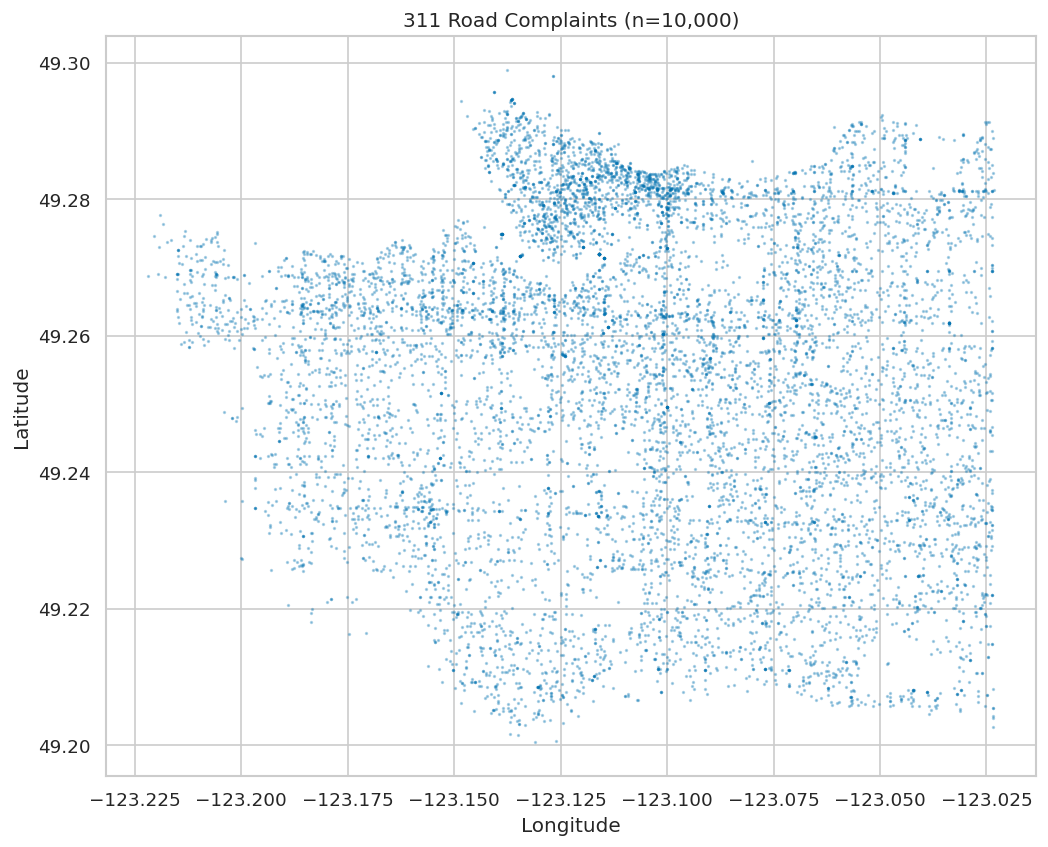

In [14]:
df_311_geo = df_311_road.dropna(subset=['Latitude','Longitude']).copy()
print(f'Road complaints with coords: {len(df_311_geo):,}')
sample = df_311_geo.sample(min(10000, len(df_311_geo)), random_state=42)
plt.figure(figsize=(10, 8))
plt.scatter(sample['Longitude'], sample['Latitude'], s=1, alpha=0.3)
plt.title(f'311 Road Complaints (n={len(sample):,})')
plt.xlabel('Longitude'); plt.ylabel('Latitude')
save_fig('04_311_spatial')
plt.show()

---
## 4. Weather Analysis (Branch 2 input)

Features: temperature, precipitation, freeze-thaw cycles, rolling accumulations (7d/30d/90d)

In [15]:
print('Columns:', df_weather.columns.tolist())
print(f'Rows: {len(df_weather):,}')
df_weather.head(2)

Columns: ['Longitude (x)', 'Latitude (y)', 'Station Name', 'Climate ID', 'Date/Time', 'Year', 'Month', 'Day', 'Data Quality', 'Max Temp (°C)', 'Max Temp Flag', 'Min Temp (°C)', 'Min Temp Flag', 'Mean Temp (°C)', 'Mean Temp Flag', 'Heat Deg Days (°C)', 'Heat Deg Days Flag', 'Cool Deg Days (°C)', 'Cool Deg Days Flag', 'Total Rain (mm)', 'Total Rain Flag', 'Total Snow (cm)', 'Total Snow Flag', 'Total Precip (mm)', 'Total Precip Flag', 'Snow on Grnd (cm)', 'Snow on Grnd Flag', 'Dir of Max Gust (10s deg)', 'Dir of Max Gust Flag', 'Spd of Max Gust (km/h)', 'Spd of Max Gust Flag']
Rows: 2,557


,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-01,2019,1,1,NaN,5.3,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
1,-123.18,49.19,VANCOUVER INTL A,1108395,2019-01-02,2019,1,2,NaN,5.5,...,0.0,T,3.4,NaN,NaN,NaN,6.0,NaN,41.0,NaN


In [16]:
# Rename columns - exclude Flag columns to avoid duplicates
w_rename = {}
for col in df_weather.columns:
    if 'Flag' in col:
        continue
    if col == 'Date/Time': w_rename[col] = 'date'
    elif 'Max Temp' in col: w_rename[col] = 'temp_max'
    elif 'Min Temp' in col: w_rename[col] = 'temp_min'
    elif 'Mean Temp' in col: w_rename[col] = 'temp_mean'
    elif 'Total Rain' in col: w_rename[col] = 'rain_mm'
    elif 'Total Snow' in col: w_rename[col] = 'snow_cm'
    elif 'Total Precip' in col: w_rename[col] = 'precip_mm'

# Drop Flag columns (data quality markers, not needed for modeling)
flag_cols = [c for c in df_weather.columns if 'Flag' in c]
df_weather = df_weather.drop(columns=flag_cols)
df_weather = df_weather.rename(columns=w_rename)
df_weather['date'] = pd.to_datetime(df_weather['date'])
df_weather = df_weather.sort_values('date').reset_index(drop=True)
print(f'Date range: {df_weather["date"].min()} -> {df_weather["date"].max()}')
print(f'Dropped {len(flag_cols)} Flag columns')

gaps = df_weather['date'].diff().dt.days
bad = gaps[gaps > 1]
print(f'Date gaps: {len(bad)}' if len(bad) > 0 else 'No date gaps - continuous daily data')

key_cols = ['temp_min','temp_max','temp_mean','rain_mm','snow_cm','precip_mm']
print(f'\nMissing values:')
print(df_weather[key_cols].isnull().sum().to_string())

Date range: 2019-01-01 00:00:00 -> 2025-12-31 00:00:00
Dropped 11 Flag columns
No date gaps - continuous daily data

Missing values:
temp_min     57
temp_max     57
temp_mean    57
rain_mm      18
snow_cm      13
precip_mm    10


In [17]:
df_weather['temp_range'] = df_weather['temp_max'] - df_weather['temp_min']
df_weather['freeze_thaw'] = ((df_weather['temp_min'] < 0) & (df_weather['temp_max'] > 0)).astype(int)
df_weather['precip_7d'] = df_weather['precip_mm'].rolling(7, min_periods=1).sum()
df_weather['precip_30d'] = df_weather['precip_mm'].rolling(30, min_periods=1).sum()
df_weather['precip_90d'] = df_weather['precip_mm'].rolling(90, min_periods=1).sum()
df_weather['ft_7d'] = df_weather['freeze_thaw'].rolling(7, min_periods=1).sum()
df_weather['ft_30d'] = df_weather['freeze_thaw'].rolling(30, min_periods=1).sum()

eng_cols = ['temp_range','freeze_thaw','precip_7d','precip_30d','precip_90d','ft_7d','ft_30d']
df_weather[eng_cols].describe().round(2)

,temp_range,freeze_thaw,precip_7d,precip_30d,precip_90d,ft_7d,ft_30d
count,2500.00,2557.00,2557.00,2557.00,2557.00,2557.00,2557.00
mean,7.15,0.10,20.55,87.37,256.98,0.67,2.85
std,2.89,0.29,22.82,64.80,150.18,1.34,4.31
min,1.20,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.10,0.00,2.60,34.70,132.60,0.00,0.00
50%,6.90,0.00,13.80,68.80,218.60,0.00,0.00
75%,9.12,0.00,30.30,125.80,363.70,1.00,5.00
max,17.30,1.00,150.00,324.90,646.30,7.00,23.00


  Saved -> figures/05_weather.png


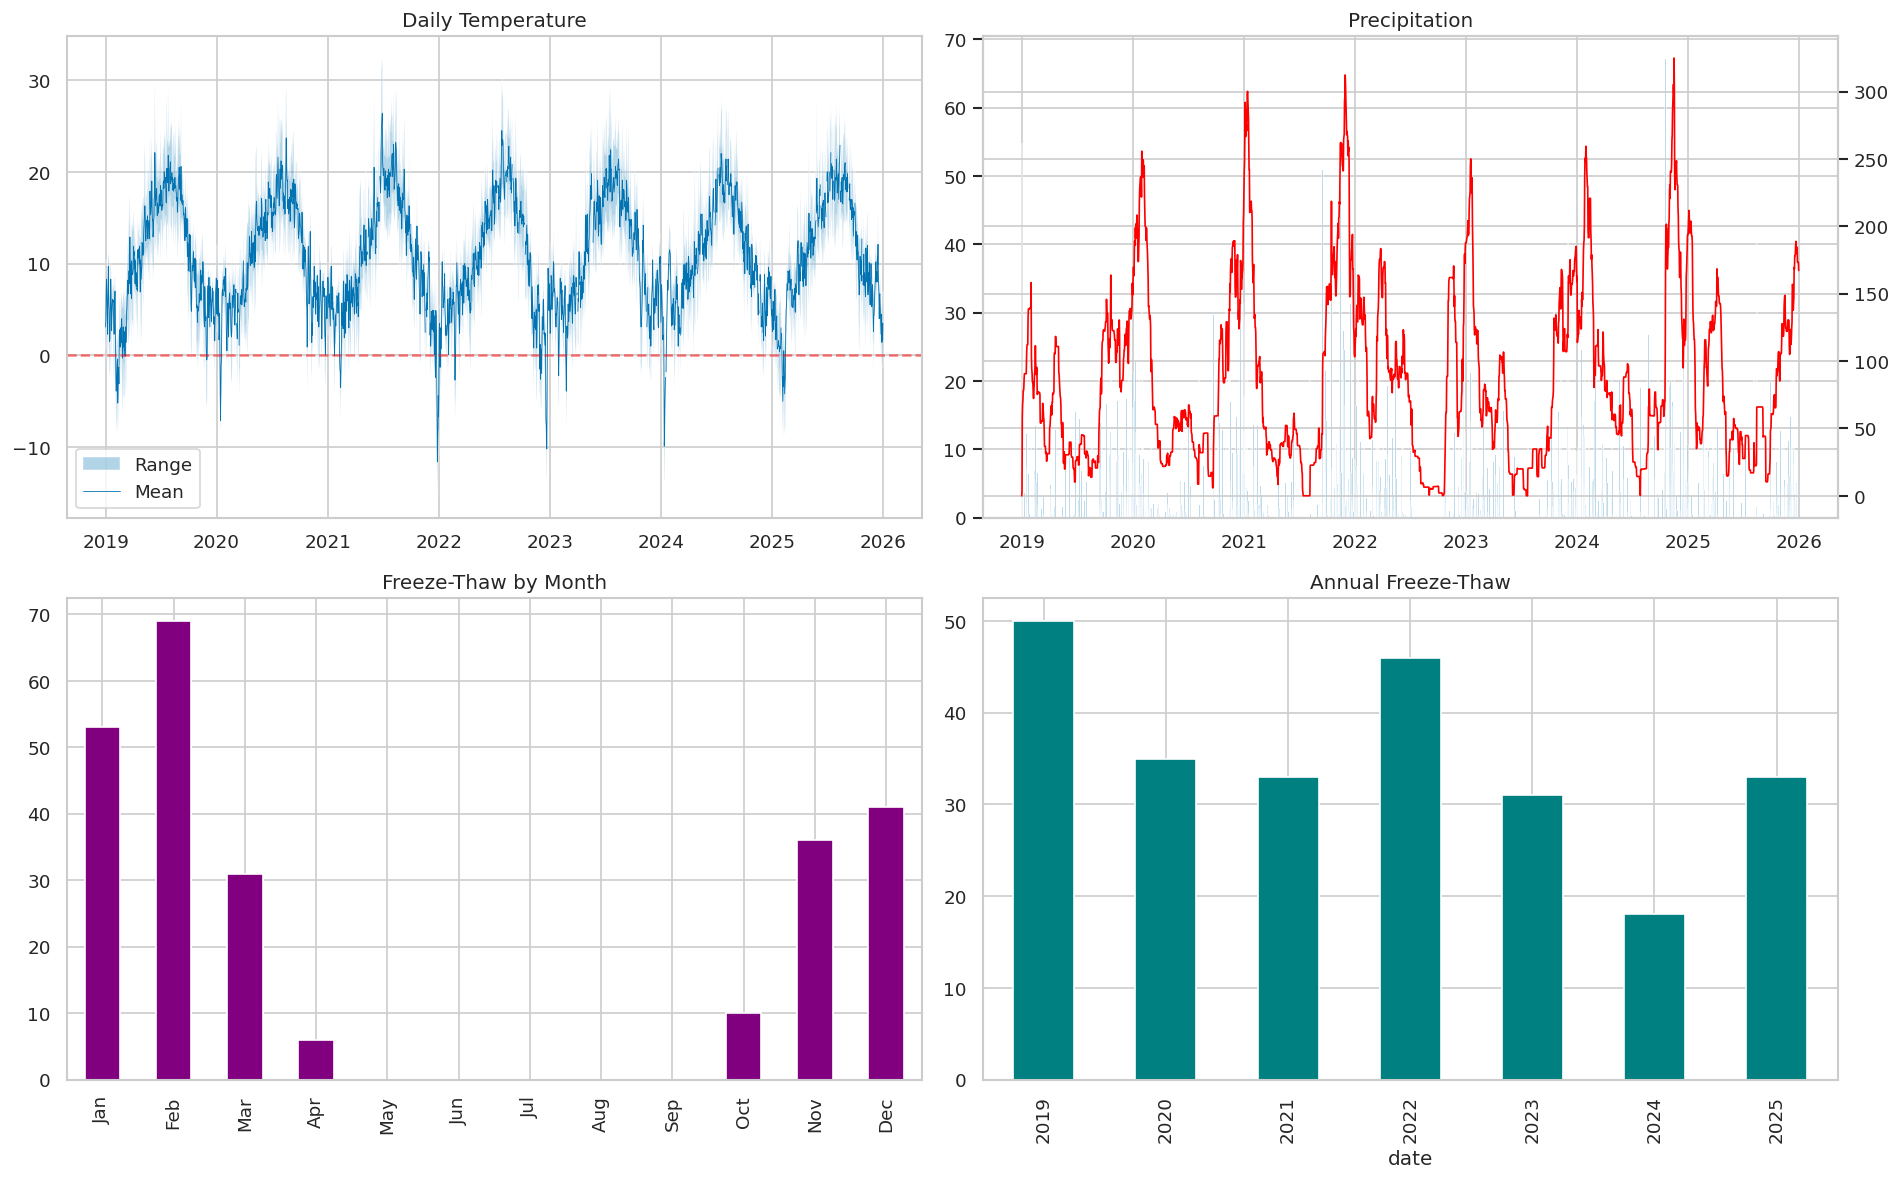

In [18]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0,0].fill_between(df_weather['date'], df_weather['temp_min'], df_weather['temp_max'], alpha=0.3, label='Range')
axes[0,0].plot(df_weather['date'], df_weather['temp_mean'], linewidth=0.5, label='Mean')
axes[0,0].axhline(0, color='red', linestyle='--', alpha=0.5)
axes[0,0].set_title('Daily Temperature'); axes[0,0].legend()

axes[0,1].bar(df_weather['date'], df_weather['precip_mm'], width=1, alpha=0.5)
ax2 = axes[0,1].twinx()
ax2.plot(df_weather['date'], df_weather['precip_30d'], color='red', linewidth=1)
axes[0,1].set_title('Precipitation')

ft_m = df_weather.groupby(df_weather['date'].dt.month)['freeze_thaw'].sum()
ft_m.index = [month_names[i-1] for i in ft_m.index]
ft_m.plot.bar(ax=axes[1,0], color='purple')
axes[1,0].set_title('Freeze-Thaw by Month')

ft_y = df_weather.groupby(df_weather['date'].dt.year)['freeze_thaw'].sum()
ft_y.plot.bar(ax=axes[1,1], color='teal')
axes[1,1].set_title('Annual Freeze-Thaw')
plt.tight_layout()
save_fig('05_weather')
plt.show()

---
## 5. Infrastructure Data (Branch 3 input)

**Note:** Traffic dataset has only locations (no volume numbers). Available features: street classification, ROW width, repair proximity.

In [19]:
for name, df in [('Streets', df_streets), ('ROW Widths', df_row),
                  ('Traffic', df_traffic), ('Repairs', df_repairs)]:
    if df is not None:
        print(f'\n=== {name} ({df.shape[0]:,} x {df.shape[1]}) ===')
        print(f'Columns: {df.columns.tolist()}')
        non_geom = [c for c in df.columns if 'geom' not in c.lower() and 'geo_' not in c.lower()]
        if non_geom: print(df[non_geom].head(3).to_string())


=== Streets (1,710 x 4) ===
Columns: ['geom', 'hblock', 'streetuse', 'geo_point_2d']
              hblock  streetuse
0     2700 E 22ND AV  Collector
1  700 W HASTINGS ST   Arterial
2     1200 ROBSON ST   Arterial

=== ROW Widths (2,690 x 3) ===
Columns: ['geom', 'width', 'geo_point_2d']
   width
0   66.0
1   66.0
2   66.0

=== Traffic (670 x 3) ===
Columns: ['location', 'geom', 'geo_point_2d']
                location
0  8000-8100 ANGUS DRIVE
1       600 VERNON DRIVE
2       2300 VENABLES ST

=== Repairs (40 x 6) ===
Columns: ['expected_completion_date', 'location', 'project_title', 'url_link', 'geom', 'geo_point_2d']
  expected_completion_date                                            location                                                                project_title                                                                                    url_link
0               2024-08-28               Oak Street and W 70th Av intersection        Oak Street Upgrades - Phase 3 (Oak Stre

  Saved -> figures/06_infrastructure.png


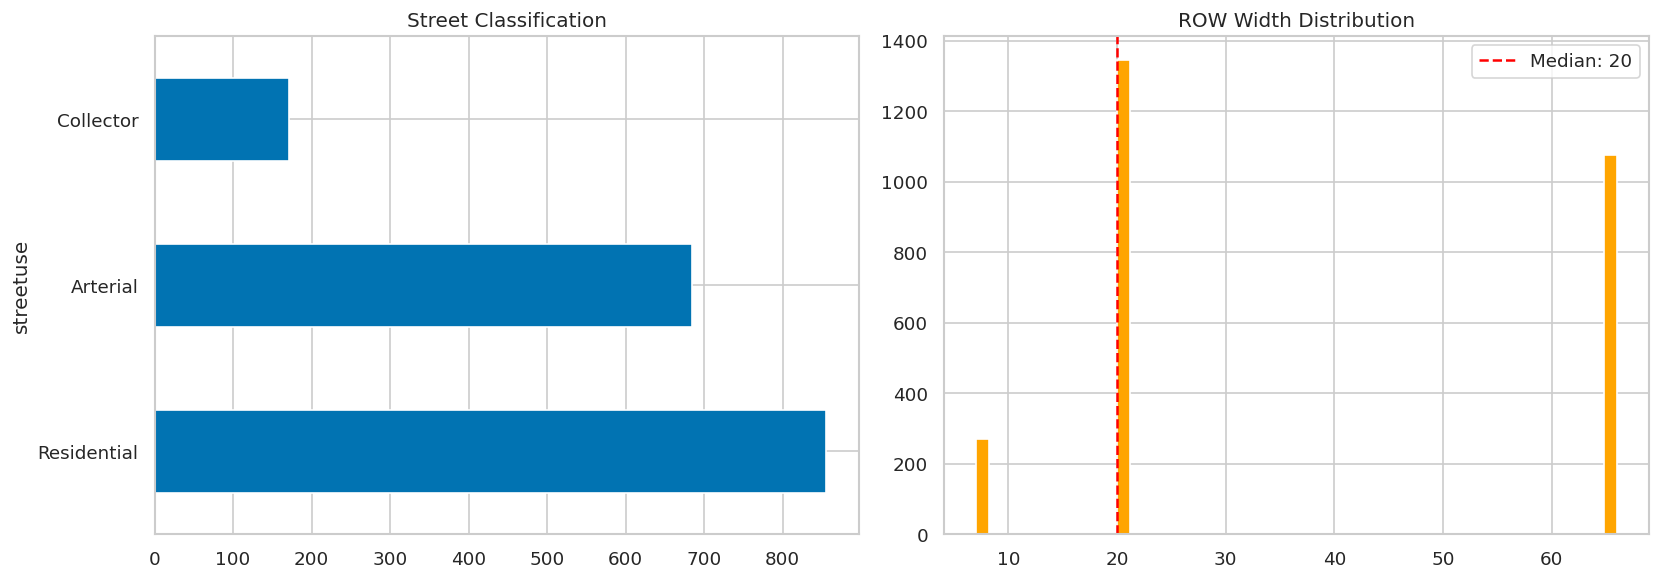

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
if df_streets is not None and 'streetuse' in df_streets.columns:
    df_streets['streetuse'].value_counts().plot.barh(ax=axes[0])
    axes[0].set_title('Street Classification')
if df_row is not None and 'width' in df_row.columns:
    df_row['width'].hist(bins=50, ax=axes[1], color='orange')
    axes[1].set_title('ROW Width Distribution')
    axes[1].axvline(df_row['width'].median(), color='red', linestyle='--',
                    label=f'Median: {df_row["width"].median():.0f}')
    axes[1].legend()
plt.tight_layout()
save_fig('06_infrastructure')
plt.show()

---
## 6. Geospatial Joins

Two geometry formats:
- Pavement: JSON (`json.loads`)
- Infrastructure: Python dict with Feature wrapper (`ast.literal_eval`)

Joins: Pavement-ROW (nearest 200m), Pavement-311 (50m buffer intersect)

In [21]:
def parse_pavement_geom(s):
    """JSON format: {coordinates: [...], type: LineString}"""
    if pd.isna(s): return None
    try: return shape(json.loads(s))
    except: return None

def parse_feature_geom(s):
    """Python dict: {type: Feature, geometry: {type: ..., coordinates: [...]}}"""
    if pd.isna(s): return None
    try:
        feat = ast.literal_eval(s)
        return shape(feat['geometry'])
    except: return None

print('Geometry parsers ready.')

Geometry parsers ready.


In [22]:
print('Parsing pavement geometries...')
pave_geoms = df_pavement['Geom'].apply(parse_pavement_geom)
valid_pave = pave_geoms.notna()
print(f'  Valid: {valid_pave.sum():,} / {len(df_pavement):,}')

gdf_pavement = gpd.GeoDataFrame(
    df_pavement[valid_pave].copy(),
    geometry=pave_geoms[valid_pave].values,
    crs='EPSG:4326'
).reset_index(drop=True)
print(f'  GeoDataFrame: {len(gdf_pavement):,} segments')

Parsing pavement geometries...
  Valid: 13,764 / 13,764
  GeoDataFrame: 13,764 segments


In [23]:
print('Parsing ROW geometries...')
row_geoms = df_row['geom'].apply(parse_feature_geom)
valid_row = row_geoms.notna()
print(f'  Valid: {valid_row.sum():,} / {len(df_row):,}')
gdf_row = gpd.GeoDataFrame(df_row[valid_row].copy(), geometry=row_geoms[valid_row].values, crs='EPSG:4326').reset_index(drop=True)

print('\nBuilding 311 GeoDataFrame...')
df_311_geo = df_311_road.dropna(subset=['Latitude','Longitude']).copy()
gdf_311 = gpd.GeoDataFrame(df_311_geo, geometry=gpd.points_from_xy(df_311_geo['Longitude'], df_311_geo['Latitude']), crs='EPSG:4326')
print(f'  311 with coords: {len(gdf_311):,}')

Parsing ROW geometries...
  Valid: 2,690 / 2,690

Building 311 GeoDataFrame...
  311 with coords: 393,406


In [24]:
UTM_CRS = 'EPSG:26910'
gdf_pave_utm = gdf_pavement.to_crs(UTM_CRS)
gdf_pave_utm['centroid'] = gdf_pave_utm.geometry.centroid
gdf_row_utm = gdf_row.to_crs(UTM_CRS)
gdf_311_utm = gdf_311.to_crs(UTM_CRS)
print(f'Projected to {UTM_CRS}:')
print(f'  Pavement: {len(gdf_pave_utm):,}')
print(f'  ROW: {len(gdf_row_utm):,}')
print(f'  311: {len(gdf_311_utm):,}')

Projected to EPSG:26910:
  Pavement: 13,764
  ROW: 2,690
  311: 393,406


In [25]:
MAX_DIST = 200
print(f'Join 1: Pavement <-> ROW Widths (max {MAX_DIST}m)...')

pave_for_join = gdf_pave_utm[['centroid']].copy().set_geometry('centroid')
row_for_join = gdf_row_utm[['geometry','width']].copy()

joined_row = gpd.sjoin_nearest(pave_for_join, row_for_join, how='left',
                                max_distance=MAX_DIST, distance_col='dist_to_row')
joined_row = joined_row[~joined_row.index.duplicated(keep='first')]

gdf_pave_utm['row_width'] = joined_row['width'].reindex(gdf_pave_utm.index).values
gdf_pave_utm['dist_to_row'] = joined_row['dist_to_row'].reindex(gdf_pave_utm.index).values

matched = gdf_pave_utm['row_width'].notna().sum()
print(f'  Matched: {matched:,} / {len(gdf_pave_utm):,} ({matched/len(gdf_pave_utm)*100:.1f}%)')
if matched > 0: print(f'  Median distance: {gdf_pave_utm["dist_to_row"].median():.1f}m')

Join 1: Pavement <-> ROW Widths (max 200m)...
  Matched: 64 / 13,764 (0.5%)
  Median distance: 136.8m


In [26]:
BUFFER_M = 50
print(f'Join 2: Pavement <-> 311 (buffer={BUFFER_M}m)...')
print(f'  May take 1-2 min with {len(gdf_311_utm):,} points...')

gdf_pave_buf = gdf_pave_utm[['geometry']].copy()
gdf_pave_buf['geometry'] = gdf_pave_buf.geometry.buffer(BUFFER_M)

joined_311 = gpd.sjoin(gdf_311_utm[['geometry']], gdf_pave_buf, how='inner', predicate='within')
complaint_counts = joined_311.groupby('index_right').size().rename('complaint_count')
gdf_pave_utm['complaint_count'] = complaint_counts.reindex(gdf_pave_utm.index).fillna(0).astype(int)

has = (gdf_pave_utm['complaint_count'] > 0).sum()
print(f'  Segments with complaints: {has:,} / {len(gdf_pave_utm):,} ({has/len(gdf_pave_utm)*100:.1f}%)')
print(gdf_pave_utm['complaint_count'].describe().round(1).to_string())

Join 2: Pavement <-> 311 (buffer=50m)...
  May take 1-2 min with 393,406 points...
  Segments with complaints: 13,753 / 13,764 (99.9%)
count    13764.0
mean       100.0
std         79.7
min          0.0
25%         50.0
50%         79.0
75%        125.0
max       1169.0


  Saved -> figures/07_complaints_vs_risk.png


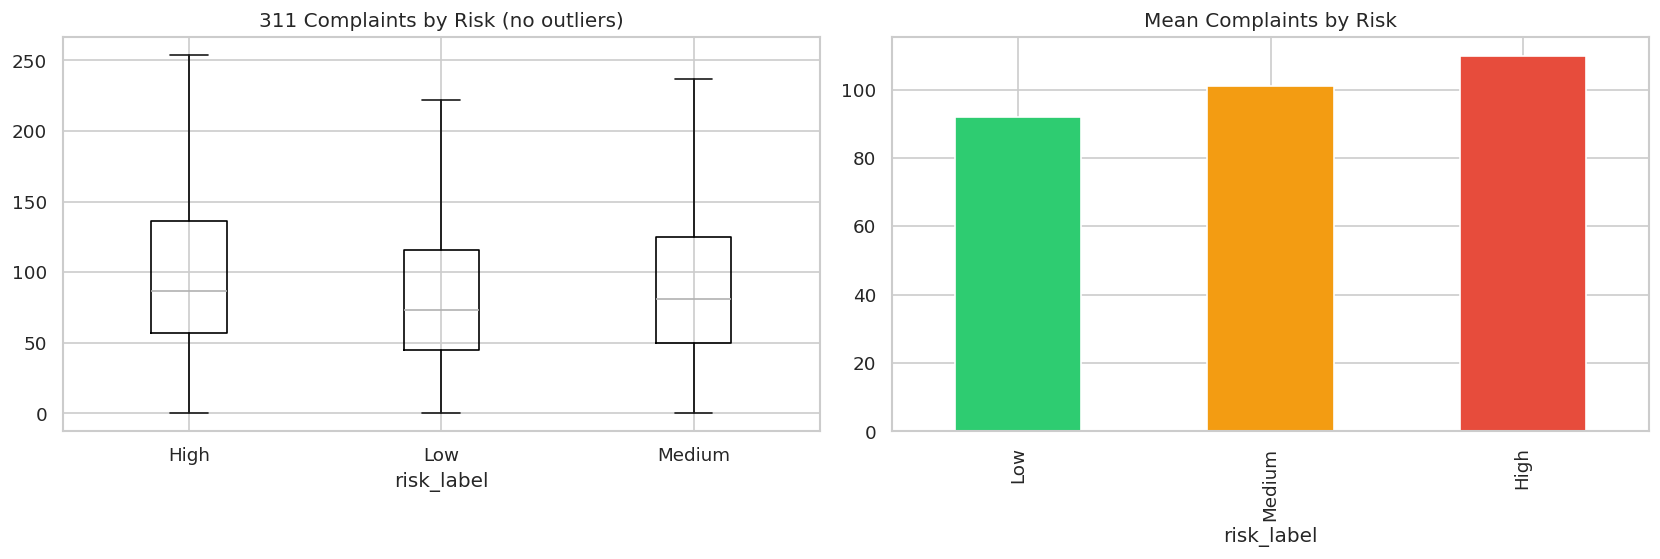

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
gdf_pave_utm.boxplot(column='complaint_count', by='risk_label', ax=axes[0], showfliers=False)
axes[0].set_title('311 Complaints by Risk (no outliers)')
plt.suptitle('')
mean_c = gdf_pave_utm.groupby('risk_label')['complaint_count'].mean()
mean_c.reindex(['Low','Medium','High']).plot.bar(ax=axes[1],
    color=[RISK_COLORS['Low'],RISK_COLORS['Medium'],RISK_COLORS['High']])
axes[1].set_title('Mean Complaints by Risk')
plt.tight_layout()
save_fig('07_complaints_vs_risk')
plt.show()

---
## 7. Correlation and Cross-Dataset Analysis

  Saved -> figures/08_correlation.png


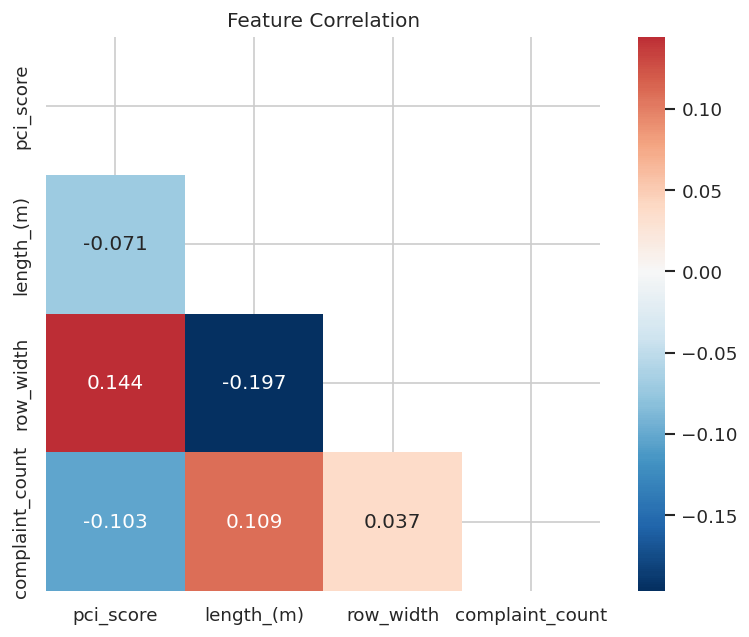

In [28]:
numeric_cols = [c for c in ['pci_score','length_(m)','row_width','complaint_count'] if c in gdf_pave_utm.columns]
if len(numeric_cols) >= 2:
    corr = gdf_pave_utm[numeric_cols].corr()
    plt.figure(figsize=(8, 6))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0, square=True)
    plt.title('Feature Correlation')
    save_fig('08_correlation')
    plt.show()

  Saved -> figures/09_weather_vs_complaints.png


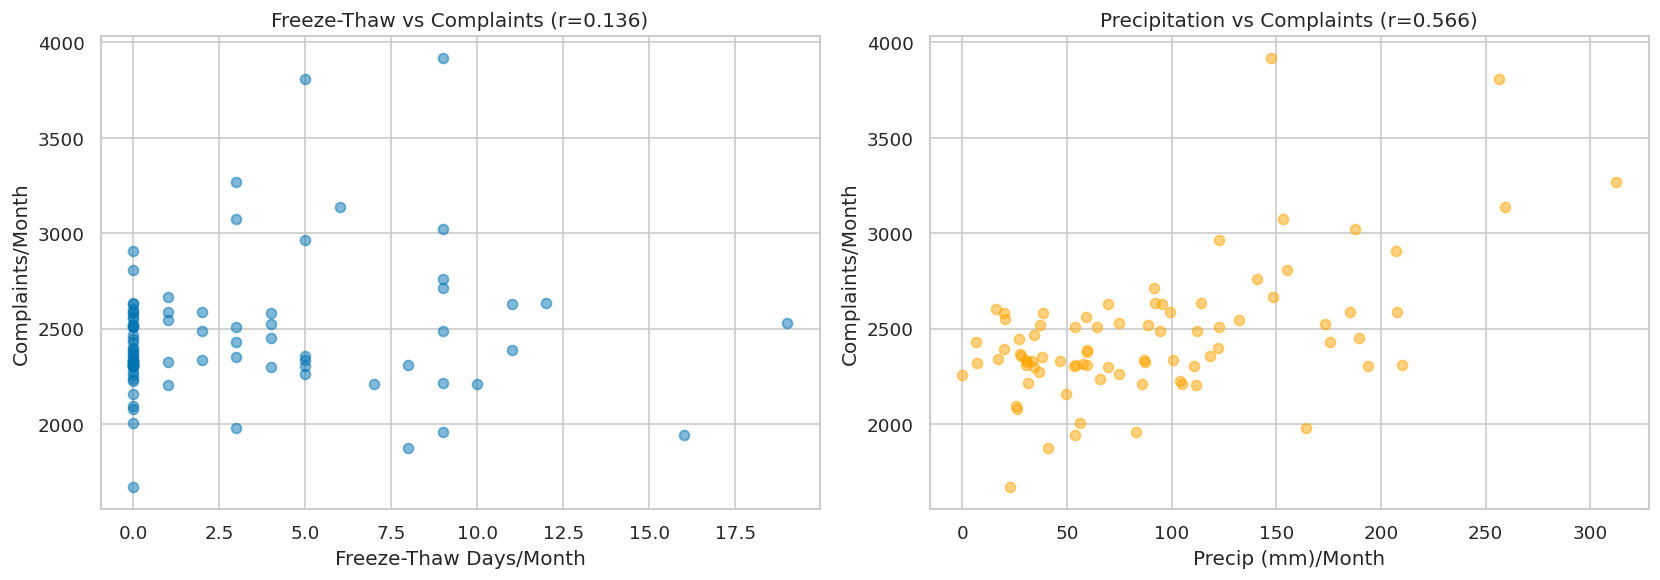

In [29]:
weather_monthly = df_weather.groupby(df_weather['date'].dt.to_period('M')).agg(
    ft_days=('freeze_thaw','sum'), total_precip=('precip_mm','sum'), mean_temp=('temp_mean','mean'))
weather_monthly.index = weather_monthly.index.to_timestamp()

complaints_monthly = df_311_road.groupby(df_311_road['date'].dt.to_period('M')).size().rename('complaints')
complaints_monthly.index = complaints_monthly.index.to_timestamp()
combined = weather_monthly.join(complaints_monthly, how='inner')

if len(combined) > 6:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].scatter(combined['ft_days'], combined['complaints'], alpha=0.5)
    axes[0].set_xlabel('Freeze-Thaw Days/Month'); axes[0].set_ylabel('Complaints/Month')
    r1 = combined[['ft_days','complaints']].corr().iloc[0,1]
    axes[0].set_title(f'Freeze-Thaw vs Complaints (r={r1:.3f})')

    axes[1].scatter(combined['total_precip'], combined['complaints'], alpha=0.5, color='orange')
    axes[1].set_xlabel('Precip (mm)/Month'); axes[1].set_ylabel('Complaints/Month')
    r2 = combined[['total_precip','complaints']].corr().iloc[0,1]
    axes[1].set_title(f'Precipitation vs Complaints (r={r2:.3f})')
    plt.tight_layout()
    save_fig('09_weather_vs_complaints')
    plt.show()

---
## 8. Train/Val/Test Split Preview

70% train / 15% val / 15% test, stratified by risk class.

In [30]:
from sklearn.model_selection import train_test_split
df_valid = gdf_pave_utm.dropna(subset=['risk_label']).copy()
train_val, test = train_test_split(df_valid, test_size=0.15, stratify=df_valid['risk_label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.176, stratify=train_val['risk_label'], random_state=42)

print('Split sizes:')
print(f'  Train: {len(train):,} ({len(train)/len(df_valid)*100:.1f}%)')
print(f'  Val:   {len(val):,} ({len(val)/len(df_valid)*100:.1f}%)')
print(f'  Test:  {len(test):,} ({len(test)/len(df_valid)*100:.1f}%)')
print()
for name, split in [('Full',df_valid),('Train',train),('Val',val),('Test',test)]:
    d = split['risk_label'].value_counts(normalize=True).round(3)
    print(f'  {name:5s}: Low={d.get("Low",0):.3f}  Med={d.get("Medium",0):.3f}  High={d.get("High",0):.3f}')

Split sizes:
  Train: 9,639 (70.0%)
  Val:   2,060 (15.0%)
  Test:  2,065 (15.0%)

  Full : Low=0.442  Med=0.222  High=0.336
  Train: Low=0.442  Med=0.222  High=0.336
  Val  : Low=0.442  Med=0.222  High=0.336
  Test : Low=0.442  Med=0.222  High=0.336


---
## 9. Summary

In [31]:
print('='*60)
print('EDA SUMMARY')
print('='*60)
print(f'\nPavement segments: {len(gdf_pave_utm):,}')
print(f'  Risk: {gdf_pave_utm["risk_label"].value_counts().to_dict()}')
print(f'\n311 road complaints: {len(df_311_road):,} (with coords: {len(df_311_geo):,})')
print(f'Weather records: {len(df_weather):,} (F-T days: {df_weather["freeze_thaw"].sum()})')
print(f'\nSpatial joins:')
print(f'  ROW matched: {gdf_pave_utm["row_width"].notna().sum():,}')
print(f'  311 matched: {(gdf_pave_utm["complaint_count"]>0).sum():,}')
print(f'\nLimitations:')
print(f'  - No PCI sub-scores (cracking, rutting); categorical only')
print(f'  - No traffic volume numbers; only locations')
print(f'  - No segment age or surface material')
print(f'  - 311 coordinate coverage ~33%')

EDA SUMMARY

Pavement segments: 13,764
  Risk: {'Low': 6080, 'High': 4623, 'Medium': 3061}

311 road complaints: 428,905 (with coords: 393,406)
Weather records: 2,557 (F-T days: 246)

Spatial joins:
  ROW matched: 64
  311 matched: 13,753

Limitations:
  - No PCI sub-scores (cracking, rutting); categorical only
  - No traffic volume numbers; only locations
  - No segment age or surface material
  - 311 coordinate coverage ~33%


In [32]:
export_cols = [c for c in gdf_pave_utm.columns if c not in ['geometry','centroid','Geom','geo_point_2d']]
df_export = pd.DataFrame(gdf_pave_utm[export_cols])
export_path = f'{DATA_DIR}/pavement_joined_features.csv'
df_export.to_csv(export_path, index=False)
print(f'Exported: {export_path}')
print(f'Shape: {df_export.shape}')
print(f'Columns: {df_export.columns.tolist()}')
df_export.head()

Exported: /content/drive/MyDrive/AI-FinalProject/data/pavement_joined_features.csv
Shape: (13764, 12)
Columns: ['Year', 'Road Name', 'From Street', 'To Street', 'length_(m)', 'PCI Rating', 'road_type', 'pci_score', 'risk_label', 'row_width', 'dist_to_row', 'complaint_count']


,Year,Road Name,From Street,To Street,length_(m),PCI Rating,road_type,pci_score,risk_label,row_width,dist_to_row,complaint_count
0,2020,47TH AV,FRONTENAC ST,KIRKLAND ST,89,GOOD,local,75.0,Low,NaN,NaN,41
1,2020,62ND AV,LABURNUM ST,ANGUS DRIVE,206,VERY POOR,local,15.0,High,NaN,NaN,51
2,2020,29TH AV,ELGIN ST,ROSS ST,101,POOR,local,35.0,High,NaN,NaN,73
3,2020,31ST AV,LANARK ST,DUMFRIES ST,93,VERY POOR,local,15.0,High,NaN,NaN,77
4,2020,53RD AV,KNIGHT ST,LANARK ST,100,VERY GOOD,local,90.0,Low,NaN,NaN,106
